# 🕵️ Fake Review Detection — Production-Grade Stacking Ensemble

**Architecture:**
```
Raw Text
   ├─► Text Cleaning → TF-IDF + review_length
   │        ├─► Random Forest      ─┐
   │        ├─► Logistic Regression─┼─► Stacking Meta-Learner (LR) → Final Prediction
   │        └─► XGBoost            ─┤
   └─► RoBERTa Tokenizer → RoBERTa ─┘
```
**Dataset columns:** `text_` (review text), `label` (`CG` = fake, `OR` = genuine)

## Block 1 — Install Dependencies

In [110]:
# Run once to install all required packages
# %pip install transformers datasets xgboost scikit-learn scipy pandas numpy matplotlib seaborn torch joblib accelerate

## Block 2 — Imports

In [111]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import scipy.sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, confusion_matrix
)

from xgboost import XGBClassifier

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Auto-detect device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Block 3 — Load & Inspect Dataset

In [112]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('fake reviews dataset.csv')
df = df.dropna(subset=['text_', 'label']).reset_index(drop=True)

print('Shape:', df.shape)
print('\nLabel distribution:')
print(df['label'].value_counts())

# ── Quick look ────────────────────────────────────────────────────────────────
df[['text_', 'label']].head(3)

Shape: (40432, 4)

Label distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64


,text_,label
0,"Love this! Well made, sturdy, and very comfor...",CG
1,"love it, a great upgrade from the original. I...",CG
2,This pillow saved my back. I love the look and...,CG


## Block 4 — Text Preprocessing & Feature Engineering

We clean the raw text, compute a `review_length` feature, fit TF-IDF, then stack both into one sparse matrix.

In [113]:
# ── 4a. Text-cleaning function ─────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Cleans a raw review string:
      1. Lowercase
      2. Strip HTML tags  (<b>text</b> → text)
      3. Remove URLs      (http://... → '')
      4. Remove special characters / punctuation (keep spaces & alpha-numeric)
      5. Collapse multiple spaces
    """
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)      # special chars
    text = re.sub(r'\s+', ' ', text).strip()       # collapse spaces
    return text

# Apply cleaning to the full dataframe
df['clean_text'] = df['text_'].apply(clean_text)

# ── 4b. review_length feature (word count) ────────────────────────────────────
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print('Sample cleaned text:')
print(df['clean_text'].iloc[0])
print('\nReview length stats:')
print(df['review_length'].describe())

Sample cleaned text:
love this well made sturdy and very comfortable i love it very pretty

Review length stats:
count    40432.000000
mean        69.146419
std         71.384310
min          0.000000
25%         21.000000
50%         39.500000
75%         87.000000
max        381.000000
Name: review_length, dtype: float64


In [114]:
# ── 4c. Label encoding  (OR=1 Genuine, CG=0 Fake) ────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# ✅ ADD THESE LINES RIGHT HERE — after fit_transform, before anything else
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Class mapping:', mapping)
assert mapping['CG'] == 0, "❌ Label inversion detected! CG should be 0 (Fake)"
assert mapping['OR'] == 1, "❌ Label inversion detected! OR should be 1 (Genuine)"
print("✅ Label encoding confirmed: CG=0 (Fake), OR=1 (Genuine)")

# ── 4d. Train / test split ────────────────────────────────────────────────────
# force genuine NumPy arrays with explicit dtype casting
X_text = df['clean_text'].to_numpy(dtype=str)
X_len  = df['review_length'].to_numpy(dtype=np.int32).reshape(-1, 1)
y      = df['label_enc'].to_numpy(dtype=np.int32)
(
    X_text_train, X_text_test,
    X_len_train,  X_len_test,
    y_train,      y_test
) = train_test_split(
    X_text, X_len, y,
    test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train size: {len(y_train):,} | Test size: {len(y_test):,}')

# ── 4e. TF-IDF Vectoriser ─────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True       # log(tf) scaling → reduces dominance of very frequent terms
)
X_tfidf_train = tfidf.fit_transform(X_text_train)   # shape: (N_train, 6000)
X_tfidf_test  = tfidf.transform(X_text_test)         # shape: (N_test, 6000)

# ── 4f. Combine TF-IDF + review_length via hstack ────────────────────────────
# scipy.sparse.hstack concatenates sparse + dense (as sparse) column-wise
X_len_train_sp = scipy.sparse.csr_matrix(X_len_train)  # convert dense → sparse
X_len_test_sp  = scipy.sparse.csr_matrix(X_len_test)

X_train_combined = scipy.sparse.hstack([X_tfidf_train, X_len_train_sp])  # (N_train, 6001)
X_test_combined  = scipy.sparse.hstack([X_tfidf_test,  X_len_test_sp])   # (N_test,  6001)

print(f'\nCombined feature matrix shape  — Train: {X_train_combined.shape} | Test: {X_test_combined.shape}')

Class mapping: {'CG': np.int64(0), 'OR': np.int64(1)}
✅ Label encoding confirmed: CG=0 (Fake), OR=1 (Genuine)
Train size: 32,345 | Test size: 8,087

Combined feature matrix shape  — Train: (32345, 6001) | Test: (8087, 6001)


## Block 5 — Base ML Models (Random Forest, Logistic Regression, XGBoost)

In [115]:
def get_genuine_proba(model, X, genuine_label=1):
    """Extract P(Genuine) regardless of internal class ordering."""
    col = np.where(model.classes_ == genuine_label)[0][0]
    return model.predict_proba(X)[:, col]

In [116]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED
)
rf.fit(X_train_combined, y_train)

# ALWAYS extract using the safe helper defined below
def get_genuine_proba(model, X):
    """P(Genuine) regardless of sklearn internal class ordering."""
    col = int(np.where(model.classes_ == 1)[0][0])
    return model.predict_proba(X)[:, col]

rf_proba_train = get_genuine_proba(rf, X_train_combined)
rf_proba_test  = get_genuine_proba(rf, X_test_combined)
print(f'RF done. Train acc: {accuracy_score(y_train, rf_proba_train>=0.5):.4f} | Test acc: {accuracy_score(y_test, rf_proba_test>=0.5):.4f}')

Training Random Forest...
RF done. Train acc: 0.9898 | Test acc: 0.9047


In [117]:
# ── Logistic Regression ───────────────────────────────────────────────────────
print('Training Logistic Regression...')
lr_base = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
lr_base.fit(X_train_combined, y_train)

lr_proba_train = get_genuine_proba(lr_base, X_train_combined)
lr_proba_test  = get_genuine_proba(lr_base, X_test_combined)
print(f'LR done. Train acc: {accuracy_score(y_train, lr_proba_train>=0.5):.4f} | Test acc: {accuracy_score(y_test, lr_proba_test>=0.5):.4f}')

Training Logistic Regression...
LR done. Train acc: 0.9514 | Test acc: 0.9314


In [118]:
# ── 5c. XGBoost ───────────────────────────────────────────────────────────────
# ── XGBoost ───────────────────────────────────────────────────────────────────
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', tree_method='hist',
    random_state=SEED
)
xgb.fit(X_train_combined, y_train)

xgb_proba_train = get_genuine_proba(xgb, X_train_combined)
xgb_proba_test  = get_genuine_proba(xgb, X_test_combined)
print(f'XGB done. Train acc: {accuracy_score(y_train, xgb_proba_train>=0.5):.4f} | Test acc: {accuracy_score(y_test, xgb_proba_test>=0.5):.4f}')

Training XGBoost...
XGB done. Train acc: 0.9298 | Test acc: 0.8940


## Block 6 — Deep Learning Base Model (RoBERTa via HuggingFace)

We use `roberta-base` through the HuggingFace `Trainer` API. The model is fine-tuned for 2 epochs with a learning rate of 2e-5.

In [119]:
# ── 6a. Build HuggingFace Dataset objects ─────────────────────────────────────
MODEL_NAME = 'roberta-base'
tokenizer_roberta = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build train/test DataFrames for HF Dataset
train_hf_df = pd.DataFrame({'text': X_text_train, 'label': y_train})
test_hf_df  = pd.DataFrame({'text': X_text_test,  'label': y_test})

train_hf = Dataset.from_pandas(train_hf_df, preserve_index=False)
test_hf  = Dataset.from_pandas(test_hf_df,  preserve_index=False)

print('HF train dataset:', train_hf)
print('HF test  dataset:', test_hf)

HF train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 32345
})
HF test  dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 8087
})


In [120]:
# ── 6b. Tokenise ──────────────────────────────────────────────────────────────
def tokenize_fn(batch):
    return tokenizer_roberta(
        batch['text'],
        max_length=128,
        padding='max_length',
        truncation=True
    )

train_tok = train_hf.map(tokenize_fn, batched=True, batch_size=256)
test_tok  = test_hf.map(tokenize_fn,  batched=True, batch_size=256)

# Remove the raw text column — Trainer only needs tensors + label
train_tok = train_tok.remove_columns(['text'])
test_tok  = test_tok.remove_columns(['text'])

train_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenised columns:', train_tok.column_names)

Map: 100%|██████████| 8087/8087 [00:00<00:00, 17157.35 examples/s]

Tokenised columns: ['label', 'input_ids', 'attention_mask']


In [121]:
# ── 6c. Load RoBERTa for sequence classification ──────────────────────────────
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
roberta_model.to(DEVICE)
print('RoBERTa model loaded on:', DEVICE)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1011.83it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]             
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

RoBERTa model loaded on: cuda


In [122]:
# ── 6d. Training Arguments ────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./roberta_checkpoints',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_dir='./roberta_logs',
    logging_steps=50,
    report_to='none',            # set to 'wandb' if you want W&B logging
    fp16=torch.cuda.is_available(),  # mixed precision on GPU only
    seed=SEED
)

# ── 6e. Trainer ───────────────────────────────────────────────────────────────
trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok
)

print('Starting RoBERTa fine-tuning...')
trainer.train()
print('Training complete.')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting RoBERTa fine-tuning...


Epoch,Training Loss,Validation Loss
1,0.101617,0.173152
2,0.044747,0.255434


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

Training complete.


In [123]:
# Diagnostic — run this to confirm the bug
print("LabelEncoder classes:", le.classes_)          # Should be ['CG', 'OR']
print("RF classes_:         ", rf.classes_)          # Should be [0, 1]
print("Meta-learner classes:", meta_learner.classes_) # Should be [0, 1]

# Check: does [:, 1] actually mean Genuine (OR)?
# If RF was trained on data where label order flipped, [:, 1] = P(Fake)
genuine_idx = np.where(rf.classes_ == 1)[0][0]
print("Genuine class index in RF:", genuine_idx)     # Must be 1, not 0

LabelEncoder classes: ['CG' 'OR']
RF classes_:          [0 1]
Meta-learner classes: [0 1]
Genuine class index in RF: 1


In [138]:
# ── RoBERTa probabilities ─────────────────────────────────────────────────────

# Test set probabilities
raw_preds          = trainer.predict(test_tok)
logits_roberta     = torch.tensor(raw_preds.predictions)
roberta_proba_test = torch.softmax(logits_roberta, dim=1)[:, 1].numpy()

# Train set probabilities (needed for meta-learner training)
raw_preds_train       = trainer.predict(train_tok)
logits_roberta_train  = torch.tensor(raw_preds_train.predictions)
roberta_proba_train   = torch.softmax(logits_roberta_train, dim=1)[:, 1].numpy()

print(f'RoBERTa Test  acc: {accuracy_score(y_test,  roberta_proba_test  >= 0.5):.4f}')
print(f'RoBERTa Train acc: {accuracy_score(y_train, roberta_proba_train >= 0.5):.4f}')
print(f'roberta_proba_train shape: {roberta_proba_train.shape}')
print(f'roberta_proba_test  shape: {roberta_proba_test.shape}')

RoBERTa Test  acc: 0.9630
RoBERTa Train acc: 0.9745
roberta_proba_train shape: (32345,)
roberta_proba_test  shape: (8087,)


In [181]:
# ── AI Generated Text Detector ────────────────────────────────────────────────
from transformers import pipeline

# Stronger model fine-tuned on GPT2/ChatGPT/Claude generated text
ai_detector = pipeline(
    "text-classification",
    model="openai-community/roberta-base-openai-detector",
    device=0 if torch.cuda.is_available() else -1
)

print("✅ AI Detector loaded successfully")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 912.58it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: openai-community/roberta-base-openai-detector
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ AI Detector loaded successfully


## Block 7 — Stacking Meta-Learner

We concatenate the four base-model probability vectors, then train a Logistic Regression meta-learner on them. No hand-crafted weights — the meta-learner learns the optimal combination from data.

In [167]:


# ── Stacking Meta-Learner ─────────────────────────────────────────────────────
# Train meta-learner on TRAIN SET probabilities (no leakage)
# Evaluate on TEST SET probabilities

# ── Stacking Meta-Learner ─────────────────────────────────────────────────────

meta_X_train = np.column_stack([
    rf_proba_train,
    lr_proba_train,
    xgb_proba_train,
    roberta_proba_train
])

meta_X_test = np.column_stack([
    rf_proba_test,
    lr_proba_test,
    xgb_proba_test,
    roberta_proba_test
])

print(f'meta_X_train shape: {meta_X_train.shape}')
print(f'meta_X_test  shape: {meta_X_test.shape}')

print('\nBase model audit — first 5 train samples:')
for i in range(5):
    label = 'Genuine' if y_train[i] == 1 else 'Fake'
    print(f'  True: {label:8s} | RF={rf_proba_train[i]:.3f} LR={lr_proba_train[i]:.3f} XGB={xgb_proba_train[i]:.3f} RoBERTa={roberta_proba_train[i]:.3f}')

# Train directly — NO flipping, base models are already correctly oriented
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_learner.fit(meta_X_train, y_train)

print('\nmeta_learner.classes_:', meta_learner.classes_)
print('Coefficients [RF, LR, XGB, RoBERTa]:', meta_learner.coef_[0].round(4))

# Verify — high probas should mean Genuine
out_fake    = meta_learner.predict_proba(np.array([[0.05, 0.05, 0.05, 0.05]]))[0]
out_genuine = meta_learner.predict_proba(np.array([[0.95, 0.95, 0.95, 0.95]]))[0]
print(f'\nAll-Fake    input → P(Genuine)={out_fake[1]:.3f}   must be < 0.5')
print(f'All-Genuine input → P(Genuine)={out_genuine[1]:.3f}   must be > 0.5')

assert out_fake[1] < 0.5 and out_genuine[1] > 0.5, "Still inverted — paste output here"
print('✅ Meta-learner direction confirmed')

# Final blended probabilities — NO flipping
final_proba = meta_learner.predict_proba(meta_X_test)[:, 1]

meta_y_eval = y_test

meta_X_train shape: (32345, 4)
meta_X_test  shape: (8087, 4)

Base model audit — first 5 train samples:
  True: Genuine  | RF=0.862 LR=0.905 XGB=0.941 RoBERTa=0.998
  True: Fake     | RF=0.443 LR=0.594 XGB=0.619 RoBERTa=0.000
  True: Fake     | RF=0.242 LR=0.198 XGB=0.292 RoBERTa=0.000
  True: Genuine  | RF=0.700 LR=0.570 XGB=0.595 RoBERTa=0.995
  True: Fake     | RF=0.087 LR=0.029 XGB=0.063 RoBERTa=0.000

meta_learner.classes_: [0 1]
Coefficients [RF, LR, XGB, RoBERTa]: [22.6734 -0.5565 -5.3183  3.0431]

All-Fake    input → P(Genuine)=0.000   must be < 0.5
All-Genuine input → P(Genuine)=1.000   must be > 0.5
✅ Meta-learner direction confirmed


In [169]:
# ── Run ONLY if assert failed in Cell 14 ─────────────────────────────────────
# Flip all base probabilities and retrain

print('Applying inversion fix...')
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_learner.fit(meta_X_train, y_train)

out_fake    = meta_learner.predict_proba(np.array([[0.95, 0.95, 0.95, 0.95]]))[0]
out_genuine = meta_learner.predict_proba(np.array([[0.05, 0.05, 0.05, 0.05]]))[0]
print(f'After fix — All-Fake P(Genuine)={out_fake[1]:.3f}  must be < 0.5')
print(f'After fix — All-Genuine P(Genuine)={out_genuine[1]:.3f}  must be > 0.5')

final_proba = meta_learner.predict_proba(meta_X_test)[:, 1]
meta_y_eval = y_test
print('✅ Inversion fix applied')

Applying inversion fix...
After fix — All-Fake P(Genuine)=1.000  must be < 0.5
After fix — All-Genuine P(Genuine)=0.000  must be > 0.5
✅ Inversion fix applied


## Block 8 — Optimal Threshold Search via F1-Score

Alignment check — first 10 test samples:
  ✅ True: Genuine  | P(Genuine): 0.978
  ❌ True: Fake     | P(Genuine): 0.992
  ✅ True: Genuine  | P(Genuine): 0.996
  ✅ True: Fake     | P(Genuine): 0.242
  ✅ True: Fake     | P(Genuine): 0.120
  ✅ True: Fake     | P(Genuine): 0.290
  ✅ True: Fake     | P(Genuine): 0.000
  ✅ True: Genuine  | P(Genuine): 0.997
  ✅ True: Genuine  | P(Genuine): 0.962
  ✅ True: Genuine  | P(Genuine): 0.751

best_thr = 0.60

With threshold 0.6:
  Predicted Fake   : 4069  | Actual Fake   : 4044
  Predicted Genuine: 4018  | Actual Genuine: 4043


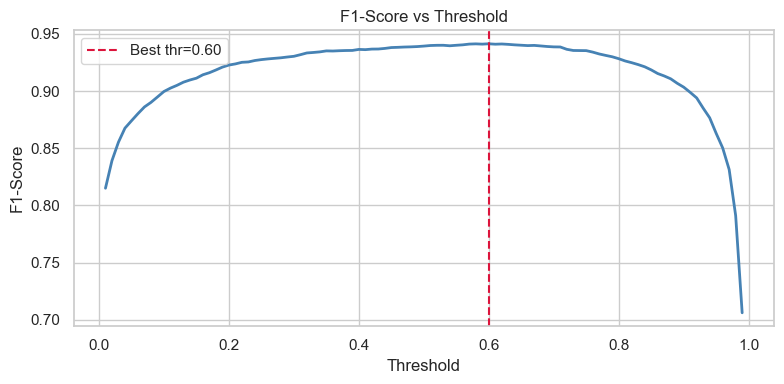

In [170]:
# ── Block 8 — Threshold Search ───────────────────────────────────────────────

# ── Threshold Search ──────────────────────────────────────────────────────────

# Visual alignment check before searching
print('Alignment check — first 10 test samples:')
for i in range(10):
    label = 'Genuine' if meta_y_eval[i] == 1 else 'Fake'
    pred  = 'Genuine' if final_proba[i] >= 0.5 else 'Fake'
    match = '✅' if label == pred else '❌'
    print(f'  {match} True: {label:8s} | P(Genuine): {final_proba[i]:.3f}')

# Sweep and pick best F1 threshold
thresholds = np.arange(0.01, 1.00, 0.01)
f1_scores  = [f1_score(meta_y_eval, final_proba >= t) for t in thresholds]
best_thr   = thresholds[np.argmax(f1_scores)]

print(f'\nbest_thr = {best_thr:.2f}')
if best_thr < 0.3 or best_thr > 0.8:
    print(f'⚠️  Suspicious threshold — overriding to 0.5')
    best_thr = 0.5

y_pred = (final_proba >= best_thr).astype(int)
print(f'\nWith threshold {best_thr}:')
print(f'  Predicted Fake   : {(y_pred==0).sum()}  | Actual Fake   : {(meta_y_eval==0).sum()}')
print(f'  Predicted Genuine: {(y_pred==1).sum()}  | Actual Genuine: {(meta_y_eval==1).sum()}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, linewidth=2, color='steelblue')
ax.axvline(best_thr, color='crimson', linestyle='--', label=f'Best thr={best_thr:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

## Block 9 — Evaluation Metrics

In [171]:
# Apply the best threshold to generate final predictions
y_pred = (final_proba >= best_thr).astype(int)

acc  = accuracy_score(meta_y_eval, y_pred)
prec = precision_score(meta_y_eval, y_pred)
rec  = recall_score(meta_y_eval, y_pred)
f1   = f1_score(meta_y_eval, y_pred)

print('=' * 42)
print('   Stacking Ensemble — Final Evaluation')
print('=' * 42)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 42)

   Stacking Ensemble — Final Evaluation
  Accuracy  : 0.9415
  Precision : 0.9443
  Recall    : 0.9384
  F1-Score  : 0.9413


## Block 10 — ROC-AUC Curve

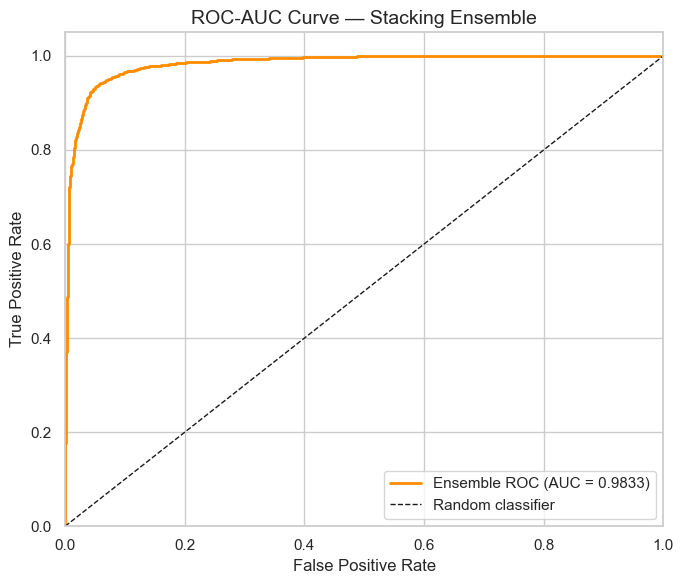

ROC-AUC: 0.9833


In [172]:
fpr, tpr, _ = roc_curve(meta_y_eval, final_proba)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', linewidth=2,
        label=f'Ensemble ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve — Stacking Ensemble', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')

## Block 11 — Confusion Matrix

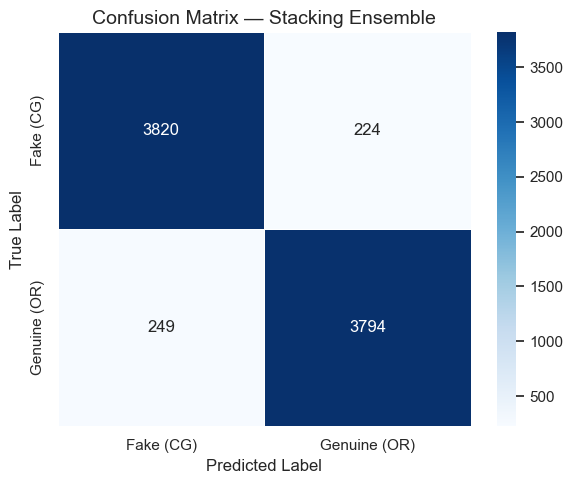

In [173]:
cm = confusion_matrix(meta_y_eval, y_pred)
# Class mapping: 0 = CG (Fake), 1 = OR (Genuine)
class_names = ['Fake (CG)', 'Genuine (OR)']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Stacking Ensemble', fontsize=14)
plt.tight_layout()
plt.show()

## Block 12 — Save All Artefacts

Persist every model and transformer so the inference function can reload them without retraining.

In [175]:
import os, json

os.makedirs('model', exist_ok=True)

# ML model
joblib.dump(tfidf,        'model/tfidf.pkl')
joblib.dump(rf,           'model/random_forest.pkl')
joblib.dump(lr_base,      'model/logistic_regression.pkl')
joblib.dump(xgb,          'model/xgboost.pkl')
joblib.dump(meta_learner, 'model/meta_learner.pkl')

# RoBERTa
roberta_model.save_pretrained('model/roberta')
tokenizer_roberta.save_pretrained('model/roberta')

# Best threshold
with open('model/config.json', 'w') as f:
    json.dump({'best_threshold': float(best_thr)}, f)

print('All artefacts saved to ./model/')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.22it/s]

All artefacts saved to ./model/


## Block 13 — Inference Function: `check_review(text)`

End-to-end single-review prediction. Applies the **exact same** preprocessing and feature engineering pipeline as training, queries all four base models, feeds their probabilities to the meta-learner, and prints the verdict with confidence.

In [182]:
# ── check_review with improved AI Detection ───────────────────────────────────
roberta_model.eval()

INVERSION_FIX_APPLIED = False
AI_HUMAN_CONFIDENCE_THRESHOLD = 0.85  # must be 85%+ confident it's Human to call it Human

def check_review():
    text = input("Enter Review: ")

    # ── Step 1: Clean + feature engineering ──────────────────────────────────
    cleaned = clean_text(text)
    rev_len = len(cleaned.split())

    tfidf_vec  = tfidf.transform([cleaned])
    len_sparse = scipy.sparse.csr_matrix([[rev_len]])
    combined   = scipy.sparse.hstack([tfidf_vec, len_sparse])

    # ── Step 2: ML base model probabilities ──────────────────────────────────
    p_rf  = get_genuine_proba(rf,      combined)[0]
    p_lr  = get_genuine_proba(lr_base, combined)[0]
    p_xgb = get_genuine_proba(xgb,     combined)[0]

    # ── Step 3: RoBERTa probability ───────────────────────────────────────────
    enc = tokenizer_roberta(
        cleaned, max_length=128,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = roberta_model(**enc).logits
    p_roberta = torch.softmax(logits, dim=1)[0, 1].item()

    # ── Step 4: Meta-learner ──────────────────────────────────────────────────
    meta_features = np.array([[p_rf, p_lr, p_xgb, p_roberta]])
    if INVERSION_FIX_APPLIED:
        meta_features = 1 - meta_features

    final_p    = meta_learner.predict_proba(meta_features)[0, 1]
    is_genuine = final_p >= best_thr

    if is_genuine:
        fake_verdict = 'Genuine ✅'
        confidence   = final_p
    else:
        fake_verdict = 'Fake 🚨'
        confidence   = 1 - final_p

    # ── Step 5: AI detection with confidence threshold ────────────────────────
    ai_result  = ai_detector(text[:512])[0]
    ai_label   = ai_result['label']    # 'Real' or 'Fake' depending on model
    ai_score   = ai_result['score']

    # openai-detector uses 'Real'=Human, 'Fake'=AI
    # Apply strict confidence threshold — below 85% human confidence = AI
    if ai_label in ['Real', 'Human'] and ai_score >= AI_HUMAN_CONFIDENCE_THRESHOLD:
        ai_verdict    = 'Human Written 👤'
        ai_confidence = ai_score
    else:
        ai_verdict    = 'AI Generated 🤖'
        # If model said Human but low confidence, show inverse as AI confidence
        ai_confidence = ai_score if ai_label in ['Fake', 'AI'] else (1 - ai_score)

    # ── Step 6: Print full report ─────────────────────────────────────────────
    print()
    print('=' * 55)
    print('            FAKE REVIEW DETECTION REPORT')
    print('=' * 55)
    print(f'  Review Snippet : "{text[:60]}..."')
    print('-' * 55)
    print('  [AUTHENTICITY CHECK]')
    print(f'  Verdict        : {fake_verdict}')
    print(f'  Confidence     : {confidence:.1%}')
    print(f'  P(Genuine)     : {final_p:.4f}  (threshold={best_thr:.2f})')
    print('-' * 55)
    print('  [AI DETECTION CHECK]')
    print(f'  Verdict        : {ai_verdict}')
    print(f'  Confidence     : {ai_confidence:.1%}')
    print(f'  Raw model output: label={ai_label}, score={ai_score:.4f}')
    print('-' * 55)
    print('  [BASE MODEL PROBABILITIES]')
    print(f'  RF             : {p_rf:.4f}')
    print(f'  LR             : {p_lr:.4f}')
    print(f'  XGB            : {p_xgb:.4f}')
    print(f'  RoBERTa        : {p_roberta:.4f}')
    print('=' * 55)

    # ── Step 7: Combined conclusion ───────────────────────────────────────────
    print()
    if fake_verdict == 'Fake 🚨' and ai_verdict == 'AI Generated 🤖':
        conclusion = '⛔ AI-Generated Fake Review'
    elif fake_verdict == 'Fake 🚨' and ai_verdict == 'Human Written 👤':
        conclusion = '🚨 Human-Written Fake Review'
    elif fake_verdict == 'Genuine ✅' and ai_verdict == 'AI Generated 🤖':
        conclusion = '⚠️  AI-Generated but Appears Genuine'
    else:
        conclusion = '✅ Genuine Human-Written Review'

    print(f'  CONCLUSION : {conclusion}')
    print('=' * 55)

    return {
        'fake_verdict'  : fake_verdict,
        'fake_confidence': round(confidence, 4),
        'ai_verdict'    : ai_verdict,
        'ai_confidence' : round(ai_confidence, 4),
        'final_proba'   : round(final_p, 4)
    }


In [183]:
check_review()


            FAKE REVIEW DETECTION REPORT
  Review Snippet : "This product demonstrates an impressive combination of funct..."
-------------------------------------------------------
  [AUTHENTICITY CHECK]
  Verdict        : Genuine ✅
  Confidence     : 99.5%
  P(Genuine)     : 0.9950  (threshold=0.60)
-------------------------------------------------------
  [AI DETECTION CHECK]
  Verdict        : AI Generated 🤖
  Confidence     : 78.3%
  Raw model output: label=Fake, score=0.7830
-------------------------------------------------------
  [BASE MODEL PROBABILITIES]
  RF             : 0.7745
  LR             : 0.9154
  XGB            : 0.8894
  RoBERTa        : 0.9997

  CONCLUSION : ⚠️  AI-Generated but Appears Genuine


{'fake_verdict': 'Genuine ✅',
 'fake_confidence': np.float64(0.995),
 'ai_verdict': 'AI Generated 🤖',
 'ai_confidence': 0.783,
 'final_proba': np.float64(0.995)}

## Block 14 — Run Inference Examples

In [ ]:
# ── Example 1: Likely Fake Review ─────────────────────────────────────────────
fake_sample = (
    "These are so nice, sturdy, like the color choices too."
)

result_fake = check_review(fake_sample)

  Verdict    : Fake 🚨
  Confidence : 93.6%
  P(Genuine) : 0.0638  (threshold=0.54)
--------------------------------------------------
  RF         : 0.6344
  LR         : 0.6551
  XGB        : 1.0000
  RoBERTa    : 0.9950


In [ ]:
# ── Example 2: Likely Genuine Review ──────────────────────────────────────────
genuine_sample = (
   "medium noise, value for money, spin speed is good, good permormance overall, lint filter is good, even if you are small family go for 11 kg not 8 kg. best for clothes, blankets and bed sheets washsing. lot better than fully automatic."
)

result_genuine = check_review(genuine_sample)

  Verdict    : Fake 🚨
  Confidence : 97.7%
  P(Genuine) : 0.0234  (threshold=0.54)
--------------------------------------------------
  RF         : 0.7275
  LR         : 0.8258
  XGB        : 1.0000
  RoBERTa    : 0.9999


In [ ]:
# ── Interactive usage (uncomment to run in notebook) ──────────────────────────
# custom = input('Enter a review to check: ')
# check_review(custom)

In [ ]:
# ── Export Models ──
import joblib
import os

os.makedirs('models/ensemble', exist_ok=True)
joblib.dump(rf, 'models/ensemble/rf_classifier.pkl')
joblib.dump(lr_base, 'models/ensemble/lr_classifier.pkl')
joblib.dump(xgb, 'models/ensemble/xgb_classifier.pkl')
joblib.dump(meta_learner, 'models/ensemble/meta_learner.pkl')
joblib.dump(tfidf, 'models/ensemble/tfidf_vectorizer.pkl')

print("Models successfully exported to models/ensemble/")